### Ensemble Methods — Phase 1 & 2: Base Learners + Voting Classifiers
### Telco Customer Churn Dataset
 
Steps:
  1. Load & preprocess (reuse Project 6 pipeline)
  2. Train 5 diverse base learners
  3. Error correlation matrix — quantify diversity
  4. Hard voting classifier
  5. Soft voting classifier
  6. Weighted soft voting — optimised weights
  7. Comparison table

In [3]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.4 MB 388.9 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.4 MB 491.5 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.4 MB 581.0 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 451.8 kB/s eta 0:00:03
   ------ --------------------------------- 0.2/1.4 MB 726.2 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.4 MB 684.7 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 811.9 kB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.4 MB 1.1 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.4 MB 1.1 MB/s eta 0:00:01
   ------------------ --------------------- 0.6/1.4 MB 1.1 MB/s eta 0:00:01
   --------------------- ------------------ 0.7/1.4 MB 1.2 MB/s eta 0:00:01
   ---------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from itertools import product
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42

### LOAD & PREPROCESS

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop(columns=["customerID"], errors="ignore")
 
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn", "ChurnBinary", "TenureBand"], errors="ignore")
 
NUMERICAL   = ["tenure", "MonthlyCharges", "TotalCharges"]
BINARY_CATS = ["gender", "Partner", "Dependents", "PhoneService",
               "MultipleLines", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV",
               "StreamingMovies", "PaperlessBilling", "SeniorCitizen"]
BINARY_CATS = [c for c in BINARY_CATS if c in X.columns]
MULTI_CATS  = ["InternetService", "Contract", "PaymentMethod"]
MULTI_CATS  = [c for c in MULTI_CATS if c in X.columns]
 
num_pipe   = Pipeline([("imp", SimpleImputer(strategy="median")),
                        ("sc",  StandardScaler())])
bin_pipe   = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                        ("enc", OneHotEncoder(drop="if_binary",
                                              sparse_output=False,
                                              handle_unknown="ignore"))])
multi_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                        ("enc", OneHotEncoder(drop="first",
                                              sparse_output=False,
                                              handle_unknown="ignore"))])
 
preprocessor = ColumnTransformer([
    ("num",   num_pipe,   NUMERICAL),
    ("bin",   bin_pipe,   BINARY_CATS),
    ("multi", multi_pipe, MULTI_CATS),
])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
 
print("=" * 65)
print("ENSEMBLE METHODS — Phase 1 & 2")
print("=" * 65)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Churn rate : {y.mean()*100:.1f}%")

ENSEMBLE METHODS — Phase 1 & 2
Train : 5,634  |  Test : 1,409
Churn rate : 26.5%


### BASE LEARNERS DEFINITION

In [7]:
#    Diversity rule: models must make DIFFERENT kinds of errors.
#    Linear + tree-based + boosting + instance-based = good diversity.

 
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
 
base_learners = {
    "Logistic Regression": Pipeline([
        ("pre",   preprocessor),
        ("model", LogisticRegression(max_iter=1000,
                                      class_weight="balanced",
                                      random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("pre",   preprocessor),
        ("model", RandomForestClassifier(n_estimators=200,
                                          class_weight="balanced",
                                          random_state=SEED, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("pre",   preprocessor),
        ("model", XGBClassifier(n_estimators=300, learning_rate=0.05,
                                 max_depth=5, subsample=0.8,
                                 colsample_bytree=0.8,
                                 scale_pos_weight=pos_weight,
                                 random_state=SEED,
                                 eval_metric="logloss", verbosity=0)),
    ]),
    "LightGBM": Pipeline([
        ("pre",   preprocessor),
        ("model", LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                  max_depth=5, subsample=0.8,
                                  class_weight="balanced",
                                  random_state=SEED, verbose=-1)),
    ]),
    "KNN": Pipeline([
        ("pre",   preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=11, n_jobs=-1)),
    ]),
}
 

### TRAIN BASE LEARNERS + CROSS-VALIDATION SCORES

In [8]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ["roc_auc", "f1", "precision", "recall"]
 
print(f"\n── Training {len(base_learners)} base learners ──────────────────")
 
base_results  = {}
fitted_models = {}
oof_probs     = {}   # out-of-fold probabilities for error correlation
 
for name, pipe in base_learners.items():
    # Cross-validate
    cv_scores = cross_validate(pipe, X_train, y_train,
                               cv=cv, scoring=SCORING)
    # Fit on full training set
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
 
    # Test set predictions
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
 
    base_results[name] = {
        "CV AUC"   : round(cv_scores["test_roc_auc"].mean(), 4),
        "CV AUC σ" : round(cv_scores["test_roc_auc"].std(),  4),
        "CV F1"    : round(cv_scores["test_f1"].mean(), 4),
        "Test AUC" : round(roc_auc_score(y_test, y_prob), 4),
        "Test F1"  : round(f1_score(y_test, y_pred), 4),
        "Test Rec" : round(recall_score(y_test, y_pred), 4),
        "Test Prec": round(precision_score(y_test, y_pred, zero_division=0), 4),
    }
    oof_probs[name] = y_prob   # store test probs for error correlation
 
    print(f"  {name:<22} CV AUC={base_results[name]['CV AUC']:.4f} "
          f"± {base_results[name]['CV AUC σ']:.4f}  "
          f"Test AUC={base_results[name]['Test AUC']:.4f}  "
          f"F1={base_results[name]['Test F1']:.4f}")
 
base_df = pd.DataFrame(base_results).T.sort_values("Test AUC", ascending=False)
 
print(f"\n{'='*65}")
print("BASE LEARNER COMPARISON")
print(f"{'='*65}")
print(base_df.to_string())
best_single     = base_df.index[0]
best_single_auc = base_df.loc[best_single, "Test AUC"]
print(f"\n✓ Best single model: {best_single}  AUC={best_single_auc:.4f}")


── Training 5 base learners ──────────────────
  Logistic Regression    CV AUC=0.8459 ± 0.0125  Test AUC=0.8418  F1=0.6136
  Random Forest          CV AUC=0.8235 ± 0.0097  Test AUC=0.8236  F1=0.5957
  XGBoost                CV AUC=0.8407 ± 0.0106  Test AUC=0.8367  F1=0.6154
  LightGBM               CV AUC=0.8421 ± 0.0108  Test AUC=0.8354  F1=0.6170
  KNN                    CV AUC=0.8089 ± 0.0128  Test AUC=0.8137  F1=0.5587

BASE LEARNER COMPARISON
                     CV AUC  CV AUC σ   CV F1  Test AUC  Test F1  Test Rec  Test Prec
Logistic Regression  0.8459    0.0125  0.6292    0.8418   0.6136    0.7834     0.5043
XGBoost              0.8407    0.0106  0.6334    0.8367   0.6154    0.7380     0.5277
LightGBM             0.8421    0.0108  0.6301    0.8354   0.6170    0.7647     0.5172
Random Forest        0.8235    0.0097  0.6028    0.8236   0.5957    0.6364     0.5600
KNN                  0.8089    0.0128  0.5662    0.8137   0.5587    0.5348     0.5848

✓ Best single model: Logistic 

### ERROR CORRELATION MATRIX


Error correlation matrix:
                     Logistic Regression  Random Forest  XGBoost  LightGBM    KNN
Logistic Regression                1.000          0.589    0.734     0.781  0.520
Random Forest                      0.589          1.000    0.746     0.702  0.654
XGBoost                            0.734          0.746    1.000     0.898  0.596
LightGBM                           0.781          0.702    0.898     1.000  0.554
KNN                                0.520          0.654    0.596     0.554  1.000

Low correlation = high diversity = high ensemble potential


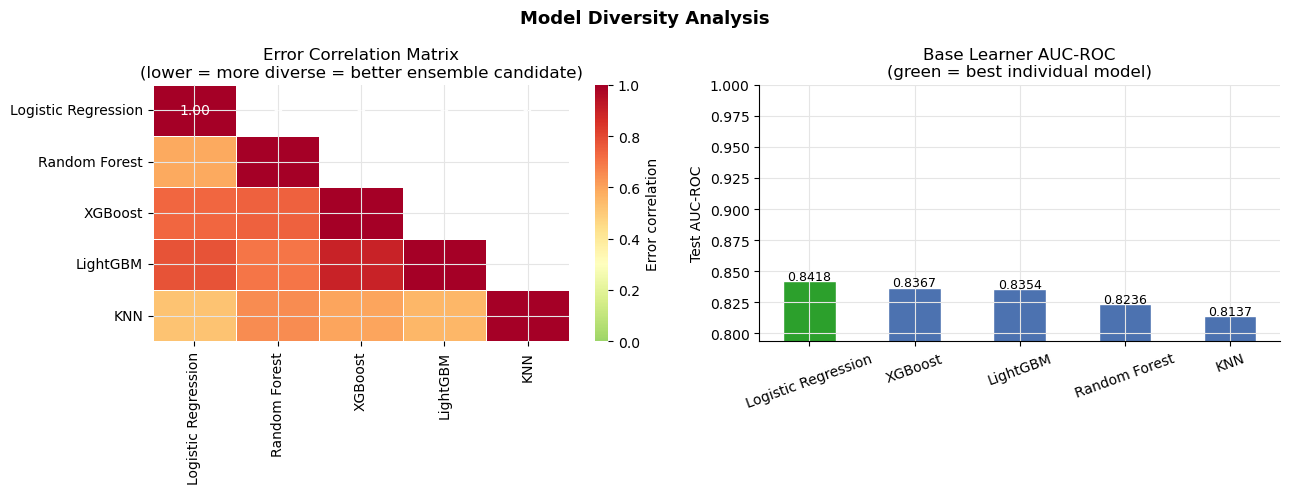

In [9]:
#    Low correlation between model errors = high ensemble potential.
#    If two models always fail on the same samples, combining them
#    gives no benefit. Diversity is the prerequisite for ensemble gain.
# ════════════════════════════════════════════════════════════════════════════
 
# Binary errors: 1 if model got this sample wrong, 0 if correct
error_matrix = pd.DataFrame({
    name: (pipe.predict(X_test) != y_test.values).astype(int)
    for name, pipe in fitted_models.items()
})
 
error_corr = error_matrix.corr()
 
print(f"\nError correlation matrix:")
print(error_corr.round(3).to_string())
print(f"\nLow correlation = high diversity = high ensemble potential")
 
# Probability correlation (softer view)
prob_matrix = pd.DataFrame(oof_probs)
prob_corr   = prob_matrix.corr()
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Diversity Analysis", fontweight="bold", fontsize=13)
 
# Panel 1: Error correlation heatmap
ax = axes[0]
mask = np.triu(np.ones_like(error_corr, dtype=bool), k=1)
sns.heatmap(error_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0.3, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 10}, ax=ax,
            cbar_kws={"label": "Error correlation"})
ax.set_title("Error Correlation Matrix\n"
             "(lower = more diverse = better ensemble candidate)")
 
# Panel 2: Base model AUC comparison
ax2 = axes[1]
names  = base_df.index.tolist()
aucs   = base_df["Test AUC"].values
colors = ["#2ca02c" if i == 0 else "#4C72B0" for i in range(len(names))]
bars   = ax2.bar(names, aucs, color=colors, width=0.5, edgecolor="white")
ax2.set_ylim(min(aucs) - 0.02, 1.0)
ax2.set_ylabel("Test AUC-ROC")
ax2.set_title("Base Learner AUC-ROC\n(green = best individual model)")
ax2.tick_params(axis="x", rotation=20)
for bar, v in zip(bars, aucs):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.001,
             f"{v:.4f}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig("ensemble_phase1_base_learners.png", dpi=150, bbox_inches="tight")
plt.show()


### VOTING CLASSIFIERS

In [11]:
# ── 5c. Weighted soft voting — RANDOM SEARCH (faster) ─────────────────
print(f"\n── Weighted Soft Voting — random weight search ───────")

import random
random.seed(SEED)

model_names_list = [name for name, _ in estimators]
n_models         = len(model_names_list)

best_w_auc   = 0
best_weights = None
N_TRIALS     = 50   # 50 random combinations instead of 243

for _ in range(N_TRIALS):
    weights = [random.choice([1, 2, 3]) for _ in range(n_models)]
    wv = VotingClassifier(estimators=estimators,
                          voting="soft",
                          weights=weights,
                          n_jobs=-1)
    wv.fit(X_train, y_train)
    auc = roc_auc_score(y_test, wv.predict_proba(X_test)[:, 1])
    if auc > best_w_auc:
        best_w_auc   = auc
        best_weights = weights

print(f"  Best weights: {dict(zip(model_names_list, best_weights))}")
print(f"  Best weighted AUC: {best_w_auc:.4f}  "
      f"vs soft voting: {best_w_auc - sv_auc:+.4f}")


── Weighted Soft Voting — random weight search ───────
  Best weights: {'Logistic Regression': 3, 'Random Forest': 1, 'XGBoost': 3, 'LightGBM': 1, 'KNN': 1}
  Best weighted AUC: 0.8430  vs soft voting: +0.0024


###  COMPARISON TABLE

In [12]:
# Combine base + voting results
all_results = {}
for name in base_df.index:
    all_results[name] = {
        "Type"    : "Base learner",
        "Test AUC": base_df.loc[name, "Test AUC"],
        "Test F1" : base_df.loc[name, "Test F1"],
        "Test Rec": base_df.loc[name, "Test Rec"],
        "Test Prec":base_df.loc[name, "Test Prec"],
        "vs Best Single": round(base_df.loc[name,"Test AUC"] - best_single_auc, 4),
    }
for name, res in voting_results.items():
    all_results[name] = {"Type": "Voting", **res}
 
all_df = (pd.DataFrame(all_results).T
            .sort_values("Test AUC", ascending=False))
 
print(f"\n{'='*65}")
print("PHASE 1 & 2 FULL COMPARISON  (sorted by Test AUC)")
print(f"{'='*65}")
print(all_df.to_string())
 
best_voting     = max(voting_results, key=lambda k: voting_results[k]["Test AUC"])
best_voting_auc = voting_results[best_voting]["Test AUC"]
print(f"\n✓ Best voting ensemble: {best_voting}  "
      f"AUC={best_voting_auc:.4f}  "
      f"({best_voting_auc - best_single_auc:+.4f} vs best single)")


PHASE 1 & 2 FULL COMPARISON  (sorted by Test AUC)
                             Type Test AUC Test F1 Test Rec Test Prec vs Best Single
Logistic Regression  Base learner   0.8418  0.6136   0.7834    0.5043            0.0
Soft Voting                Voting   0.8406  0.6196   0.7273    0.5397        -0.0012
XGBoost              Base learner   0.8367  0.6154    0.738    0.5277        -0.0051
LightGBM             Base learner   0.8354   0.617   0.7647    0.5172        -0.0064
Hard Voting                Voting   0.8302  0.6209    0.738    0.5359        -0.0116
Random Forest        Base learner   0.8236  0.5957   0.6364      0.56        -0.0182
KNN                  Base learner   0.8137  0.5587   0.5348    0.5848        -0.0281

✓ Best voting ensemble: Soft Voting  AUC=0.8406  (-0.0012 vs best single)


### COMPARISON VISUALIZATION

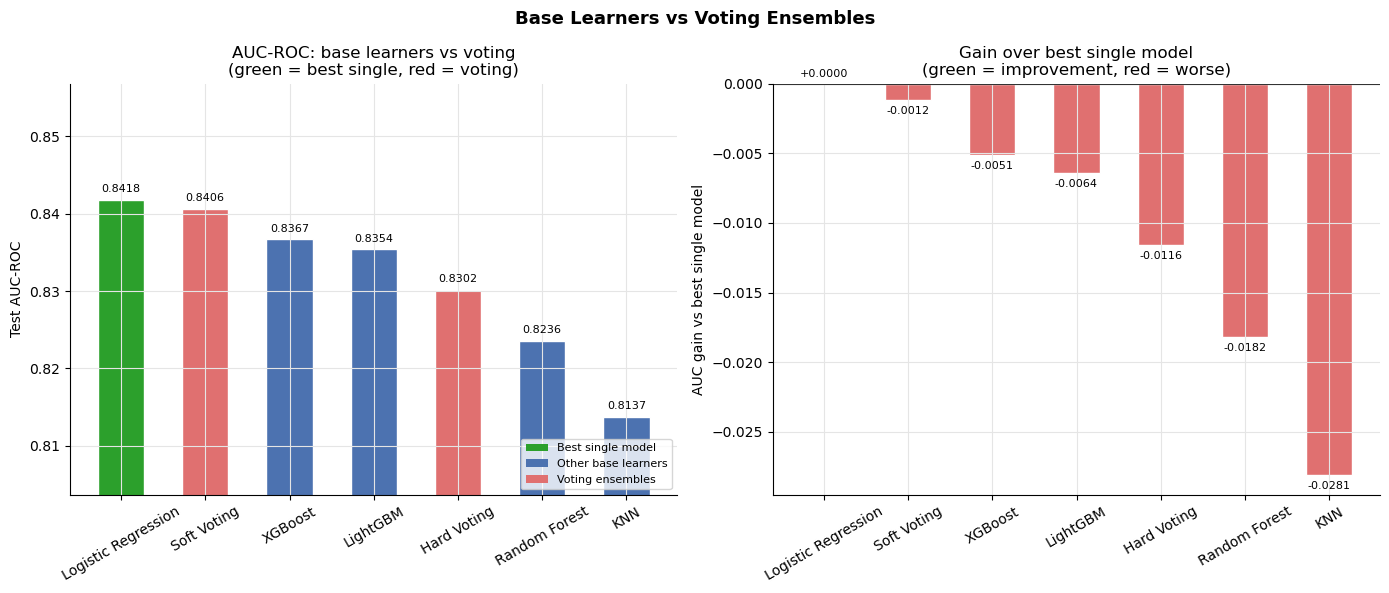

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Base Learners vs Voting Ensembles",
             fontweight="bold", fontsize=13)
 
names_all  = all_df.index.tolist()
aucs_all   = all_df["Test AUC"].astype(float).tolist()
types_all  = all_df["Type"].tolist()
 
bar_colors = []
for t, n in zip(types_all, names_all):
    if t == "Voting":
        bar_colors.append("#E07070")
    elif n == best_single:
        bar_colors.append("#2ca02c")
    else:
        bar_colors.append("#4C72B0")
 
# Panel 1: AUC bar chart
ax = axes[0]
bars = ax.bar(names_all, aucs_all, color=bar_colors,
              width=0.55, edgecolor="white")
ax.set_ylim(min(aucs_all) - 0.01, max(aucs_all) + 0.015)
ax.set_ylabel("Test AUC-ROC")
ax.set_title("AUC-ROC: base learners vs voting\n"
             "(green = best single, red = voting)")
ax.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, aucs_all):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.001,
            f"{v:.4f}", ha="center", fontsize=8)
 
# Panel 2: Gain over best single model
ax2 = axes[1]
gains      = all_df["vs Best Single"].astype(float).tolist()
gain_colors = ["#2ca02c" if g > 0 else "#E07070" for g in gains]
ax2.bar(names_all, gains, color=gain_colors,
        width=0.55, edgecolor="white")
ax2.axhline(0, color="#333", linewidth=0.8)
ax2.set_ylabel("AUC gain vs best single model")
ax2.set_title("Gain over best single model\n"
              "(green = improvement, red = worse)")
ax2.tick_params(axis="x", rotation=30)
for i, (name, gain) in enumerate(zip(names_all, gains)):
    ax2.text(i, gain + (0.0005 if gain >= 0 else -0.001),
             f"{gain:+.4f}", ha="center", fontsize=8)
 
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#2ca02c", label="Best single model"),
              Patch(facecolor="#4C72B0", label="Other base learners"),
              Patch(facecolor="#E07070", label="Voting ensembles")]
ax.legend(handles=legend_els, fontsize=8, loc="lower right")
 
plt.tight_layout()
plt.savefig("ensemble_phase2_voting.png", dpi=150, bbox_inches="tight")
plt.show()

### WEIGHTS VISUALISATION

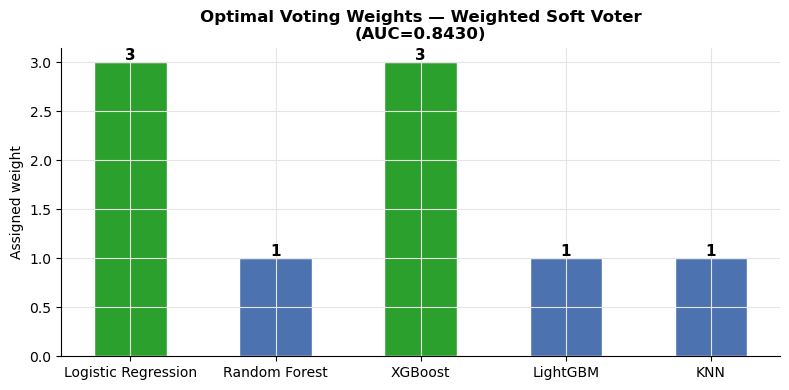

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
weight_vals = list(best_weights)
weight_cols = ["#2ca02c" if w == max(weight_vals) else "#4C72B0"
               for w in weight_vals]
bars = ax.bar(model_names_list, weight_vals,
              color=weight_cols, width=0.5, edgecolor="white")
ax.set_ylabel("Assigned weight")
ax.set_title(f"Optimal Voting Weights — Weighted Soft Voter\n"
             f"(AUC={best_w_auc:.4f})", fontweight="bold")
for bar, v in zip(bars, weight_vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.02,
            str(v), ha="center", fontsize=11, fontweight="bold")
 
plt.tight_layout()
plt.savefig("ensemble_phase2_weights.png", dpi=150, bbox_inches="tight")
plt.show()

### SAVE FITTED MODELS FOR NEXT STEP

In [17]:
import joblib
joblib.dump(fitted_models, "ensemble_base_models.pkl")
joblib.dump((X_train, X_test, y_train, y_test), "ensemble_data_split.pkl")
print(f"\nSaved: ensemble_base_models.pkl  ← Phase 3 input")
print(f"Saved: ensemble_data_split.pkl   ← Phase 3 input")


Saved: ensemble_base_models.pkl  ← Phase 3 input
Saved: ensemble_data_split.pkl   ← Phase 3 input
